<a href="https://colab.research.google.com/github/gkhamis04/George-Khamis/blob/main/Ola_Bike_Ride_Request_Forecast_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import os

files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Done 🚀")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Done 🚀


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("palvinder2006/ola-bike-ride-request")

print("Path to dataset files:", path)

100%|██████████| 171k/171k [00:00<00:00, 676kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/palvinder2006/ola-bike-ride-request/versions/1


In [3]:
import os
import shutil
shutil.copytree(path, "./data",  dirs_exist_ok=True)
print("Done! 🚀")

Done! 🚀


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_absolute_error as mae

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('/content/data/ola.csv')
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,3,2,6.66,76.62,9.57,5,128,133
1,2011-01-01 01:00:00,4,3,13.54,55.91,4.01,36,184,220
2,2011-01-01 02:00:00,1,3,29.58,20.97,33.61,34,97,131
3,2011-01-01 03:00:00,3,1,7.40,61.64,15.85,6,47,53
4,2011-01-01 04:00:00,3,4,30.66,98.71,11.47,14,199,213


In [6]:
df.shape

(10886, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   weather     10886 non-null  int64  
 3   temp        10886 non-null  float64
 4   humidity    10886 non-null  float64
 5   windspeed   10886 non-null  float64
 6   casual      10886 non-null  int64  
 7   registered  10886 non-null  int64  
 8   count       10886 non-null  int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 765.6+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.493937,1.120531,1.0,1.0000,2.00,3.0000,4.00
weather,10886.0,2.491916,1.123139,1.0,1.0000,2.00,4.0000,4.00
temp,10886.0,20.137973,8.696625,5.0,12.6300,20.19,27.7075,35.00
humidity,10886.0,59.946072,22.987200,20.0,40.0400,59.97,79.6200,99.98
windspeed,10886.0,24.960981,14.424684,0.0,12.5225,25.00,37.4275,49.99
casual,10886.0,24.517545,14.390014,0.0,12.0000,25.00,37.0000,49.00
registered,10886.0,99.551442,57.541131,0.0,50.0000,100.00,149.0000,199.00
count,10886.0,124.068988,59.449265,0.0,74.0000,124.00,174.0000,248.00


In [9]:
df["datetime"] = pd.to_datetime(df["datetime"])
df['hour'] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year
df["weekday"] = df["datetime"].dt.weekday
df["is_weekend"] = (df["datetime"].dt.weekday >= 5).astype(int)
df['am_or_pm'] = (df['hour'] > 11).astype(int)
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,hour,day,month,year,weekday,is_weekend,am_or_pm
0,2011-01-01 00:00:00,3,2,6.66,76.62,9.57,5,128,133,0,1,1,2011,5,1,0
1,2011-01-01 01:00:00,4,3,13.54,55.91,4.01,36,184,220,1,1,1,2011,5,1,0
2,2011-01-01 02:00:00,1,3,29.58,20.97,33.61,34,97,131,2,1,1,2011,5,1,0
3,2011-01-01 03:00:00,3,1,7.40,61.64,15.85,6,47,53,3,1,1,2011,5,1,0
4,2011-01-01 04:00:00,3,4,30.66,98.71,11.47,14,199,213,4,1,1,2011,5,1,0


In [10]:
import holidays
india_holidays = holidays.country_holidays("IN")
df["holidays"] = df["datetime"].dt.date.isin(india_holidays).astype(int)

In [11]:
df = df.drop('datetime', axis=1)
df.head()

,season,weather,temp,humidity,windspeed,casual,registered,count,hour,day,month,year,weekday,is_weekend,am_or_pm,holidays
0,3,2,6.66,76.62,9.57,5,128,133,0,1,1,2011,5,1,0,0
1,4,3,13.54,55.91,4.01,36,184,220,1,1,1,2011,5,1,0,0
2,1,3,29.58,20.97,33.61,34,97,131,2,1,1,2011,5,1,0,0
3,3,1,7.40,61.64,15.85,6,47,53,3,1,1,2011,5,1,0,0
4,3,4,30.66,98.71,11.47,14,199,213,4,1,1,2011,5,1,0,0


In [12]:
df.isnull().sum()

,0
season,0
weather,0
temp,0
humidity,0
windspeed,0
casual,0
registered,0
count,0
hour,0
day,0


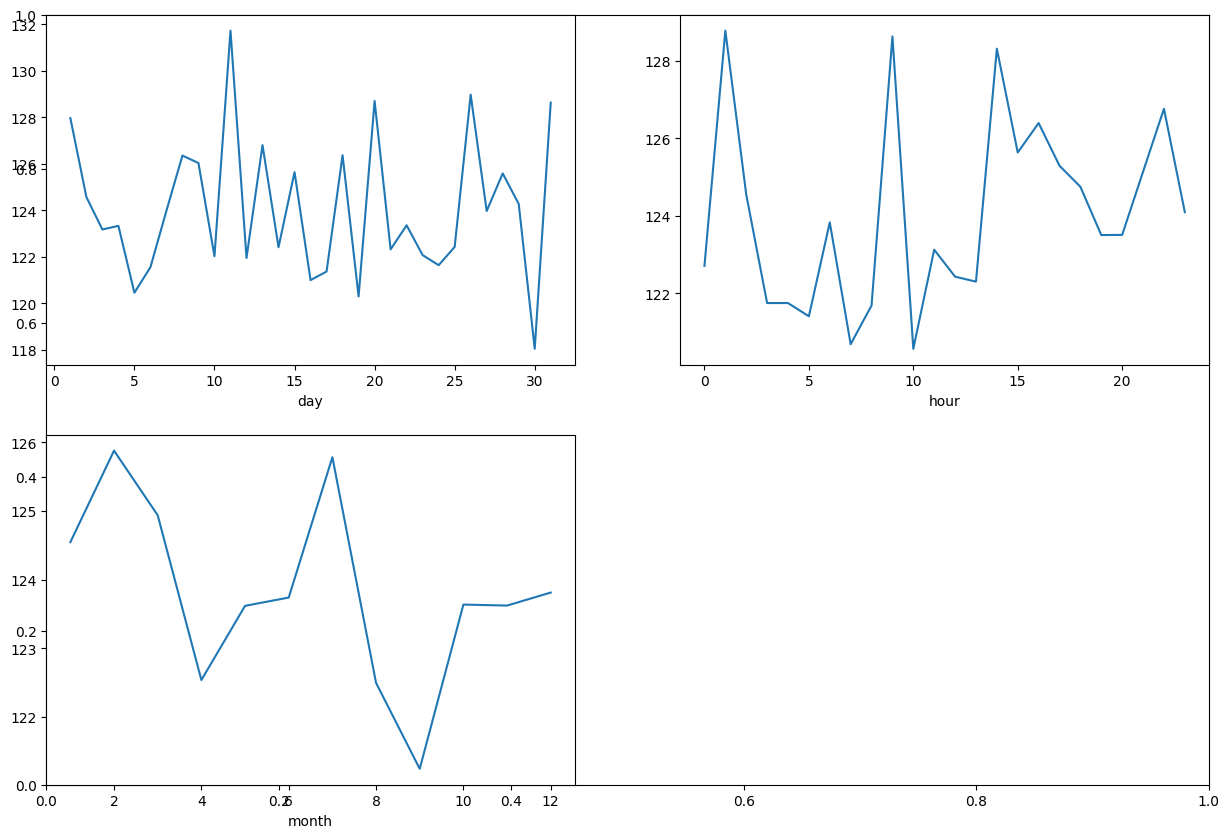

In [13]:
features = ['day', 'hour', 'month']

plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    df.groupby(col).mean()['count'].plot()
plt.show()

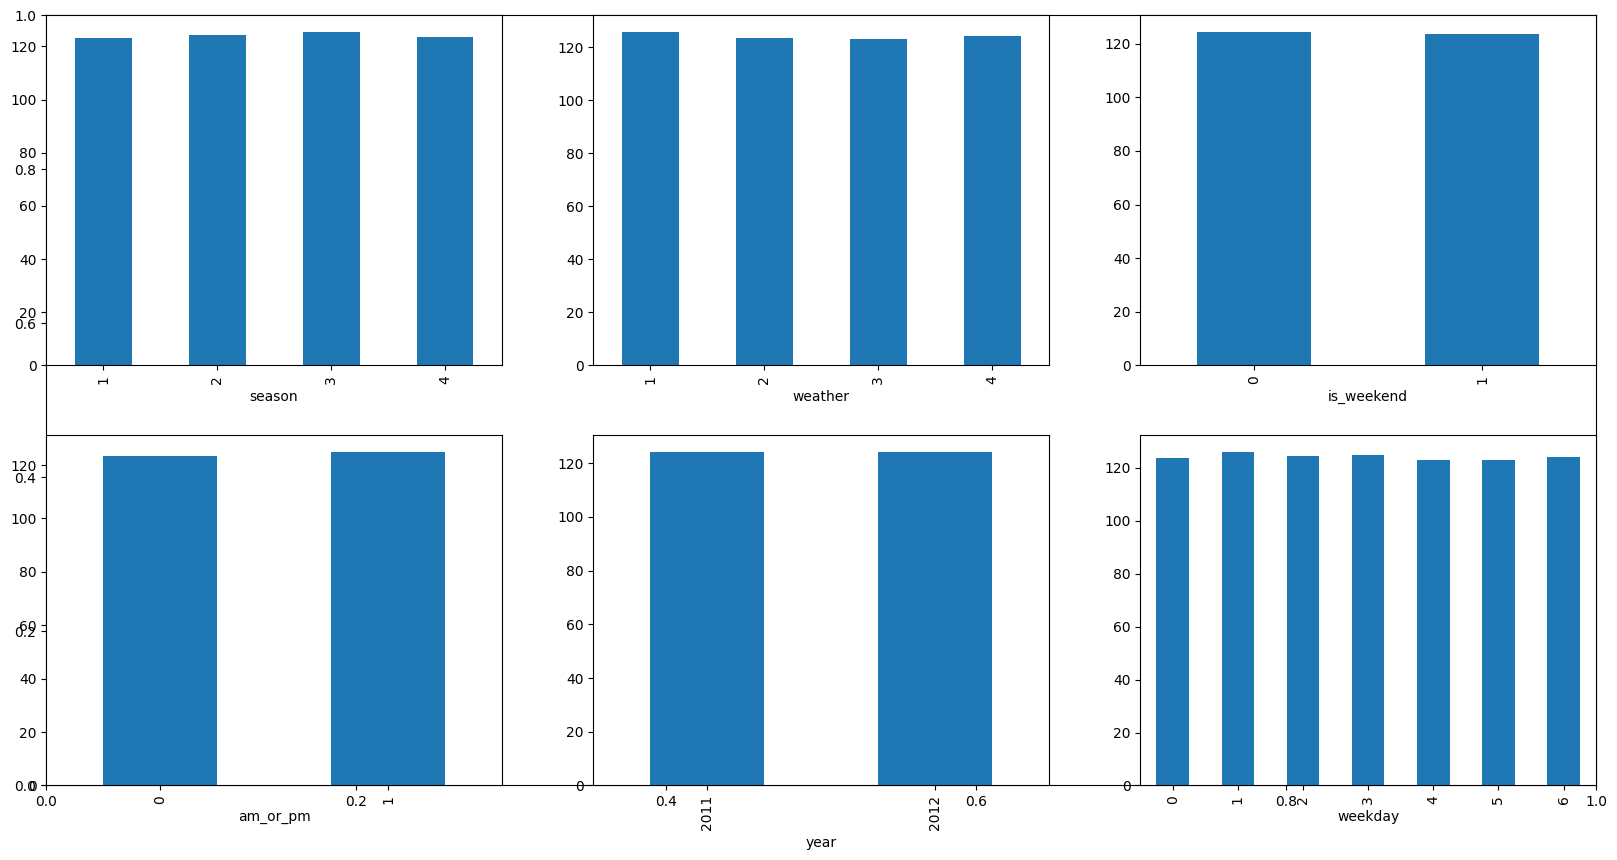

In [14]:
features = ['season', 'weather', 'is_weekend',
            'am_or_pm', 'year', 'weekday']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    df.groupby(col).mean()['count'].plot.bar()
plt.show()

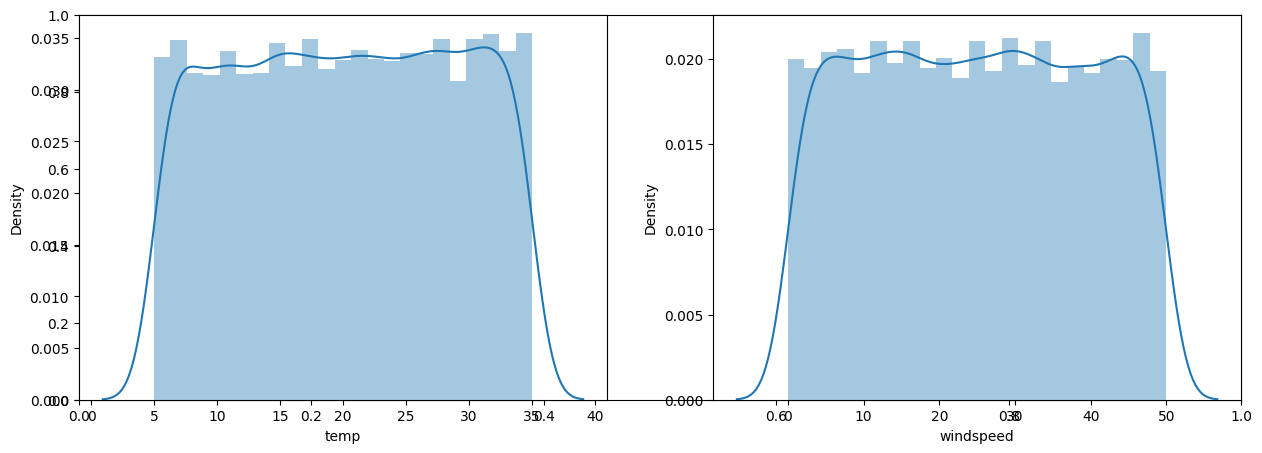

In [15]:
features = ['temp', 'windspeed']

plt.subplots(figsize=(15, 5))
for i, col in enumerate(features):
  plt.subplot(1, 2, i + 1)
  sns.distplot(df[col])
plt.show()

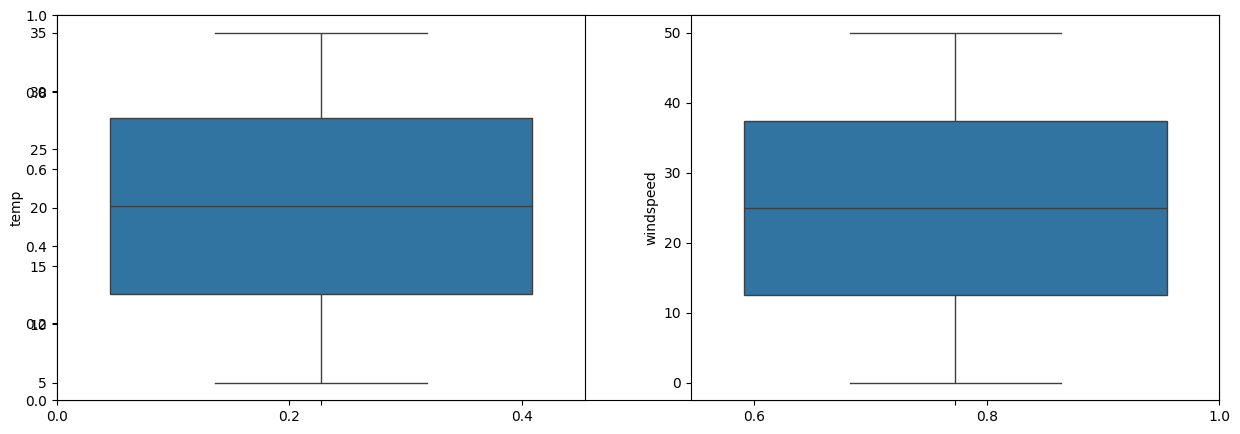

In [16]:
features = ['temp', 'windspeed']

plt.subplots(figsize=(15, 5))
for i, col in enumerate(features):
  plt.subplot(1, 2, i + 1)
  sns.boxplot(df[col])
plt.show()

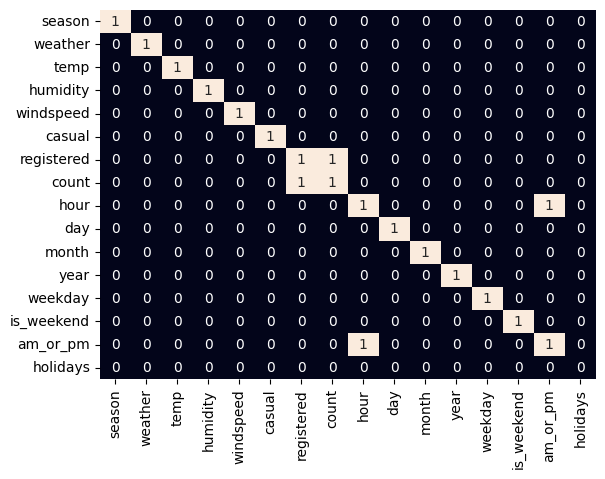

In [17]:
sns.heatmap(df.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()

In [18]:
df.drop(['registered', 'hour'], axis=1, inplace=True)
df = df[(df['windspeed'] < 32) & (df['humidity'] > 0)]

In [19]:
features = df.drop(['count'], axis=1)
target = df['count'].values

X_train, X_val, Y_train, Y_val = train_test_split(features,
                                                  target,
                                                  test_size = 0.1,
                                                  random_state=22)
X_train.shape, X_val.shape

((6295, 13), (700, 13))

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [21]:
models = [LinearRegression(), Lasso(), RandomForestRegressor(), Ridge()]

for i in range(len(models)):
    models[i].fit(X_train, Y_train)

    print(f'{models[i]} :')

    train_preds = models[i].predict(X_train)
    print('Training Error : ', mae(Y_train, train_preds))

    val_preds = models[i].predict(X_val)
    print('Validation Error : ', mae(Y_val, val_preds))
    print()

LinearRegression() :
Training Error :  49.76503818517271
Validation Error :  49.49858184694008

Lasso() :
Training Error :  49.806780458411176
Validation Error :  49.372163863241035

RandomForestRegressor() :
Training Error :  18.655795075456712
Validation Error :  50.804671428571424

Ridge() :
Training Error :  49.76502341742348
Validation Error :  49.4985164460184

